# Irreducible mass of Black Holes

Rotating BH have a irreducible mass wich is function of the gravitational mass due to Penrose process. The relation between the two can be written as:
$$
M_{irr} = M f(\chi) = M \sqrt{\frac{1 + \sqrt{1 - \chi^2 }}{2}}
$$
We procede normalizing at 1 the true value.

In [43]:
mu = 1.0
sigma = 0.02

In [44]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import astropy.visualization.hist as hist


In [45]:
def f_chi(x):
    return 1/(np.sqrt(2*np.pi)*sigma) * np.exp(-(x-mu)**2/(2*sigma**2))

def Mirr(M, chi):
    return M * np.sqrt(0.5*(1+np.sqrt(1-chi**2)))

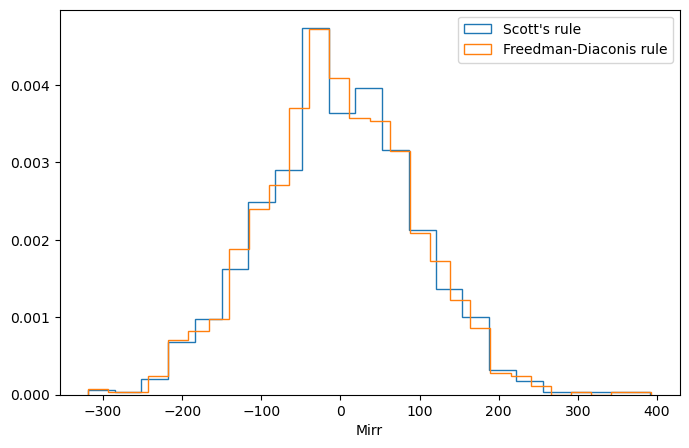

In [55]:
nsample = 1000

chi_sample = np.random.uniform(0,1, nsample)
M_sample = np.random.normal(mu, sigma, nsample)

Mirr_sample = Mirr(M_sample, chi_sample)

plt.figure(figsize=(8, 5))
hist(Mirr_sample, bins="scott", histtype="step",density=True, label="Scott's rule")
hist(Mirr_sample, bins="freedman", histtype="step",density=True, label="Freedman-Diaconis rule")
plt.xlabel("Mirr")
plt.legend()

In [47]:
from sklearn.neighbors import KernelDensity

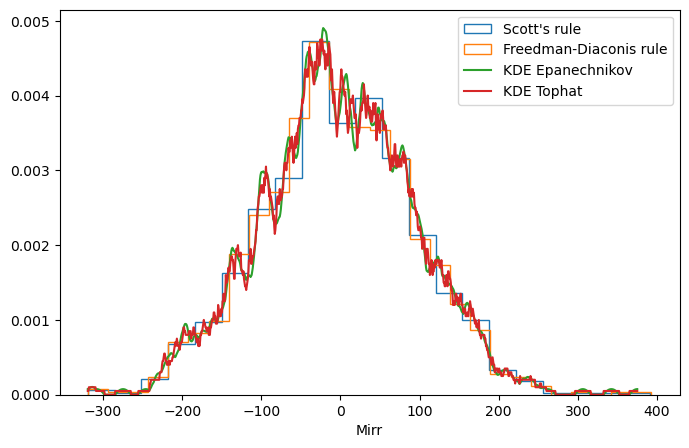

In [62]:
bandwidth = 10

kde_epanechnikov = KernelDensity(bandwidth=bandwidth, kernel="epanechnikov")
kde_tophat = KernelDensity(bandwidth=bandwidth, kernel="tophat")

kde_epanechnikov.fit(Mirr_sample[:, np.newaxis])
kde_tophat.fit(Mirr_sample[:, np.newaxis])

xgrid = np.linspace(Mirr_sample.min(), Mirr_sample.max(), 1000)

pdf_epanechnikov = np.exp(kde_epanechnikov.score_samples(xgrid[:, np.newaxis]))
pdf_tophat = np.exp(kde_tophat.score_samples(xgrid[:, np.newaxis]))

plt.figure(figsize=(8, 5))
hist(Mirr_sample, bins="scott", histtype="step",density=True, label="Scott's rule")
hist(Mirr_sample, bins="freedman", histtype="step",density=True, label="Freedman-Diaconis rule")
plt.plot(xgrid, pdf_epanechnikov, "-", label="KDE Epanechnikov")
plt.plot(xgrid, pdf_tophat, "-", label="KDE Tophat")
plt.xlabel("Mirr")
plt.legend()
plt.show()

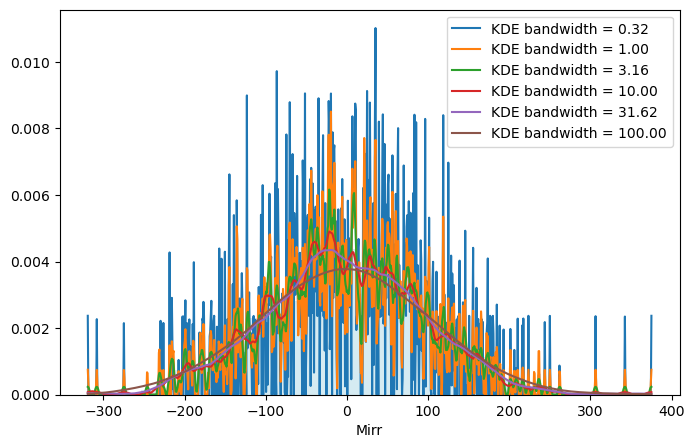

In [72]:
range_bandwidth = np.logspace(-0.5, 2, 6)

pdf_list = []

for bandwidth in range_bandwidth:
    kde_epanechnikov = KernelDensity(bandwidth=bandwidth, kernel="epanechnikov")

    kde_epanechnikov.fit(Mirr_sample[:, np.newaxis])

    xgrid = np.linspace(Mirr_sample.min(), Mirr_sample.max(), 1000)

    pdf_epanechnikov = np.exp(kde_epanechnikov.score_samples(xgrid[:, np.newaxis]))

    pdf_list.append((bandwidth, pdf_epanechnikov))

plt.figure(figsize=(8, 5))
plt.hist(Mirr_sample, bins="scott", density=True, color="lightblue", alpha=0.5)
for bandwidth, pdf in pdf_list:
    plt.plot(xgrid, pdf, "-", label="KDE bandwidth = {:.2f}".format(bandwidth))
plt.xlabel("Mirr")
plt.legend()

### KS test

Distence beetween two distibution can be study non parametrically thanks to a concept of distance that depends only from the cumulative function. We have:

$$ D = \mathrm{max}_x|F_1(x) - F_2(x)|$$

where $0\leq D\leq 1$. 
The probability of having a given distance doesn't depend on pdf, this tell us that confidence p-value and KS distance are intimitly releted.

$$ D_\mathrm{KS} = \sqrt{ -\frac{\ln(\alpha/2)}{ 2n_e}}$$

In [ ]:
D_Mirr_M_sample = stats.ks_2samp(Mirr_sample, M_sample)

print("KS statistic (Mirr vs M_sample):", D_Mirr_M_sample.statistic)
print("p-value (Mirr vs M_sample):", D_Mirr_M_sample.pvalue)

KS statistic (Mirr vs M_sample): 0.029
p-value (Mirr vs M_sample): 0.7946637387576738


/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


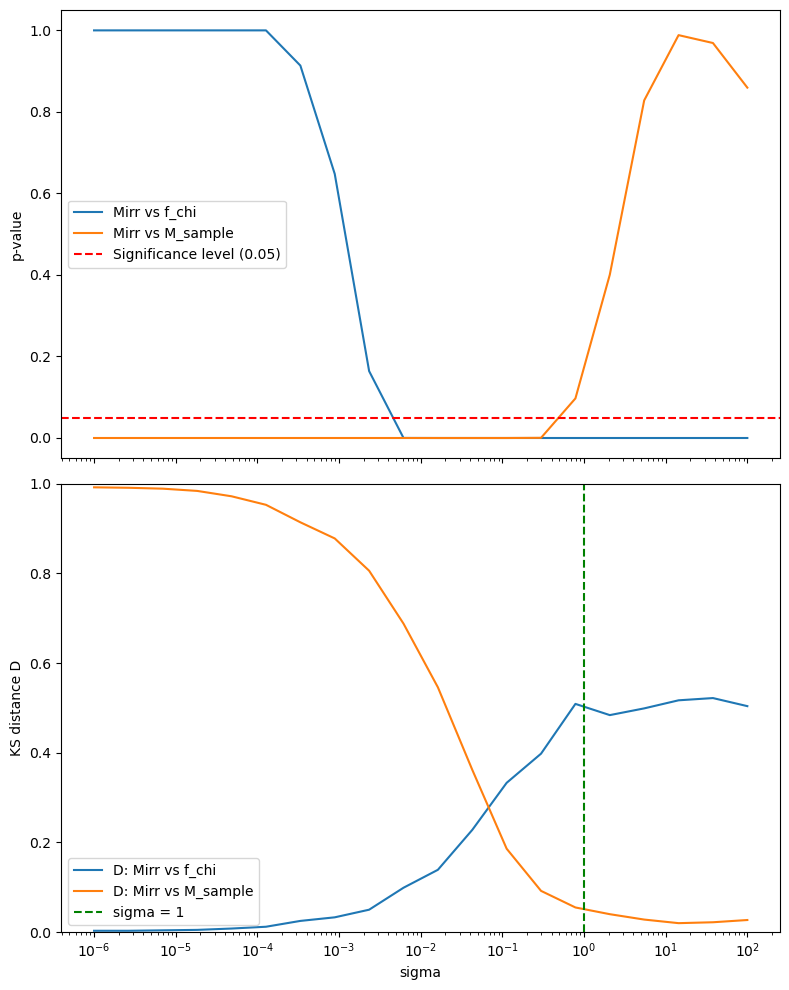

In [80]:
sigma_n = np.logspace(-6, 2, 20)

p_values_Mirr_f_chi = []
p_values_Mirr_M_sample = []
D_values_Mirr_f_chi = []
D_values_Mirr_M_sample = []

for sigma in sigma_n:
    M_sample = np.random.normal(mu, sigma, nsample)
    Mirr_sample = Mirr(M_sample, chi_sample)
    f = Mirr_sample/M_sample

    D_values_Mirr_f_chi.append(stats.ks_2samp(Mirr_sample, f).statistic)
    D_values_Mirr_M_sample.append(stats.ks_2samp(Mirr_sample, M_sample).statistic)
    p_values_Mirr_f_chi.append(stats.ks_2samp(Mirr_sample, f).pvalue)
    p_values_Mirr_M_sample.append(stats.ks_2samp(Mirr_sample, M_sample).pvalue)

fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

axes[0].plot(sigma_n, p_values_Mirr_f_chi, label="Mirr vs f_chi")
axes[0].plot(sigma_n, p_values_Mirr_M_sample, label="Mirr vs M_sample")
axes[0].set_xscale("log")
axes[0].set_ylabel("p-value")
axes[0].axhline(y=0.05, color="r", linestyle="--", label="Significance level (0.05)")
axes[0].legend()

axes[1].plot(sigma_n, D_values_Mirr_f_chi, label="D: Mirr vs f_chi")
axes[1].plot(sigma_n, D_values_Mirr_M_sample, label="D: Mirr vs M_sample")
axes[1].set_xscale("log")
axes[1].set_xlabel("sigma")
axes[1].set_ylabel("KS distance D")
axes[1].set_ylim(0, 1)
axes[1].axvline(x=1, color="g", linestyle="--", label="sigma = 1")
axes[1].legend()

plt.tight_layout()
plt.show()